In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch
print(torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
True


In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pkdarabi/bone-fracture-detection-computer-vision-project


In [ ]:
!rm -rf /content/fracture_data
!unzip -q /content/bone-fracture-detection-computer-vision-project.zip -d /content/fracture_data
!find /content/fracture_data -maxdepth 3

/content/fracture_data
/content/fracture_data/bone fracture detection.v4-v4.yolov8
/content/fracture_data/bone fracture detection.v4-v4.yolov8/valid
/content/fracture_data/bone fracture detection.v4-v4.yolov8/valid/labels
/content/fracture_data/bone fracture detection.v4-v4.yolov8/valid/images
/content/fracture_data/bone fracture detection.v4-v4.yolov8/data.yaml
/content/fracture_data/bone fracture detection.v4-v4.yolov8/test
/content/fracture_data/bone fracture detection.v4-v4.yolov8/test/labels
/content/fracture_data/bone fracture detection.v4-v4.yolov8/test/images
/content/fracture_data/bone fracture detection.v4-v4.yolov8/README.dataset.txt
/content/fracture_data/bone fracture detection.v4-v4.yolov8/train
/content/fracture_data/bone fracture detection.v4-v4.yolov8/train/labels
/content/fracture_data/bone fracture detection.v4-v4.yolov8/train/images
/content/fracture_data/BoneFractureYolo8
/content/fracture_data/BoneFractureYolo8/valid
/content/fracture_data/BoneFractureYolo8/valid/

In [ ]:
import os
from collections import Counter

label_dir = '/content/fracture_data/BoneFractureYolo8/train/labels'
class_counts = Counter()

for fname in os.listdir(label_dir):
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

names = ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive']
for idx, count in sorted(class_counts.items()):
    print(f"{idx}: {names[idx]} -> {count} instances")


0: elbow positive -> 339 instances
1: fingers positive -> 531 instances
2: forearm fracture -> 316 instances
3: humerus fracture -> 3 instances
4: humerus -> 311 instances
5: shoulder fracture -> 360 instances
6: wrist positive -> 228 instances


In [ ]:
import os

old_to_new = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3, 5: 4, 6: 5}
base = '/content/fracture_data/BoneFractureYolo8'

for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base, split, 'labels')
    for fname in os.listdir(label_dir):
        path = os.path.join(label_dir, fname)
        new_lines = []
        with open(path) as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                old_class = int(parts[0])
                new_class = old_to_new[old_class]
                parts[0] = str(new_class)
                new_lines.append(' '.join(parts))
        with open(path, 'w') as f:
            f.write('\n'.join(new_lines) + '\n')

print("Remapping done.")

Remapping done.


In [ ]:
yaml_content = """train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'shoulder fracture', 'wrist positive']
"""

with open('/content/fracture_data/BoneFractureYolo8/data.yaml', 'w') as f:
    f.write(yaml_content)

print(open('/content/fracture_data/BoneFractureYolo8/data.yaml').read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'shoulder fracture', 'wrist positive']



In [ ]:
import os
from collections import Counter

label_dir = '/content/fracture_data/BoneFractureYolo8/train/labels'
class_counts = Counter()

for fname in os.listdir(label_dir):
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

names = ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'shoulder fracture', 'wrist positive']
for idx, count in sorted(class_counts.items()):
    print(f"{idx}: {names[idx]} -> {count} instances")

0: elbow positive -> 339 instances
1: fingers positive -> 531 instances
2: forearm fracture -> 316 instances
3: humerus fracture -> 314 instances
4: shoulder fracture -> 360 instances
5: wrist positive -> 228 instances


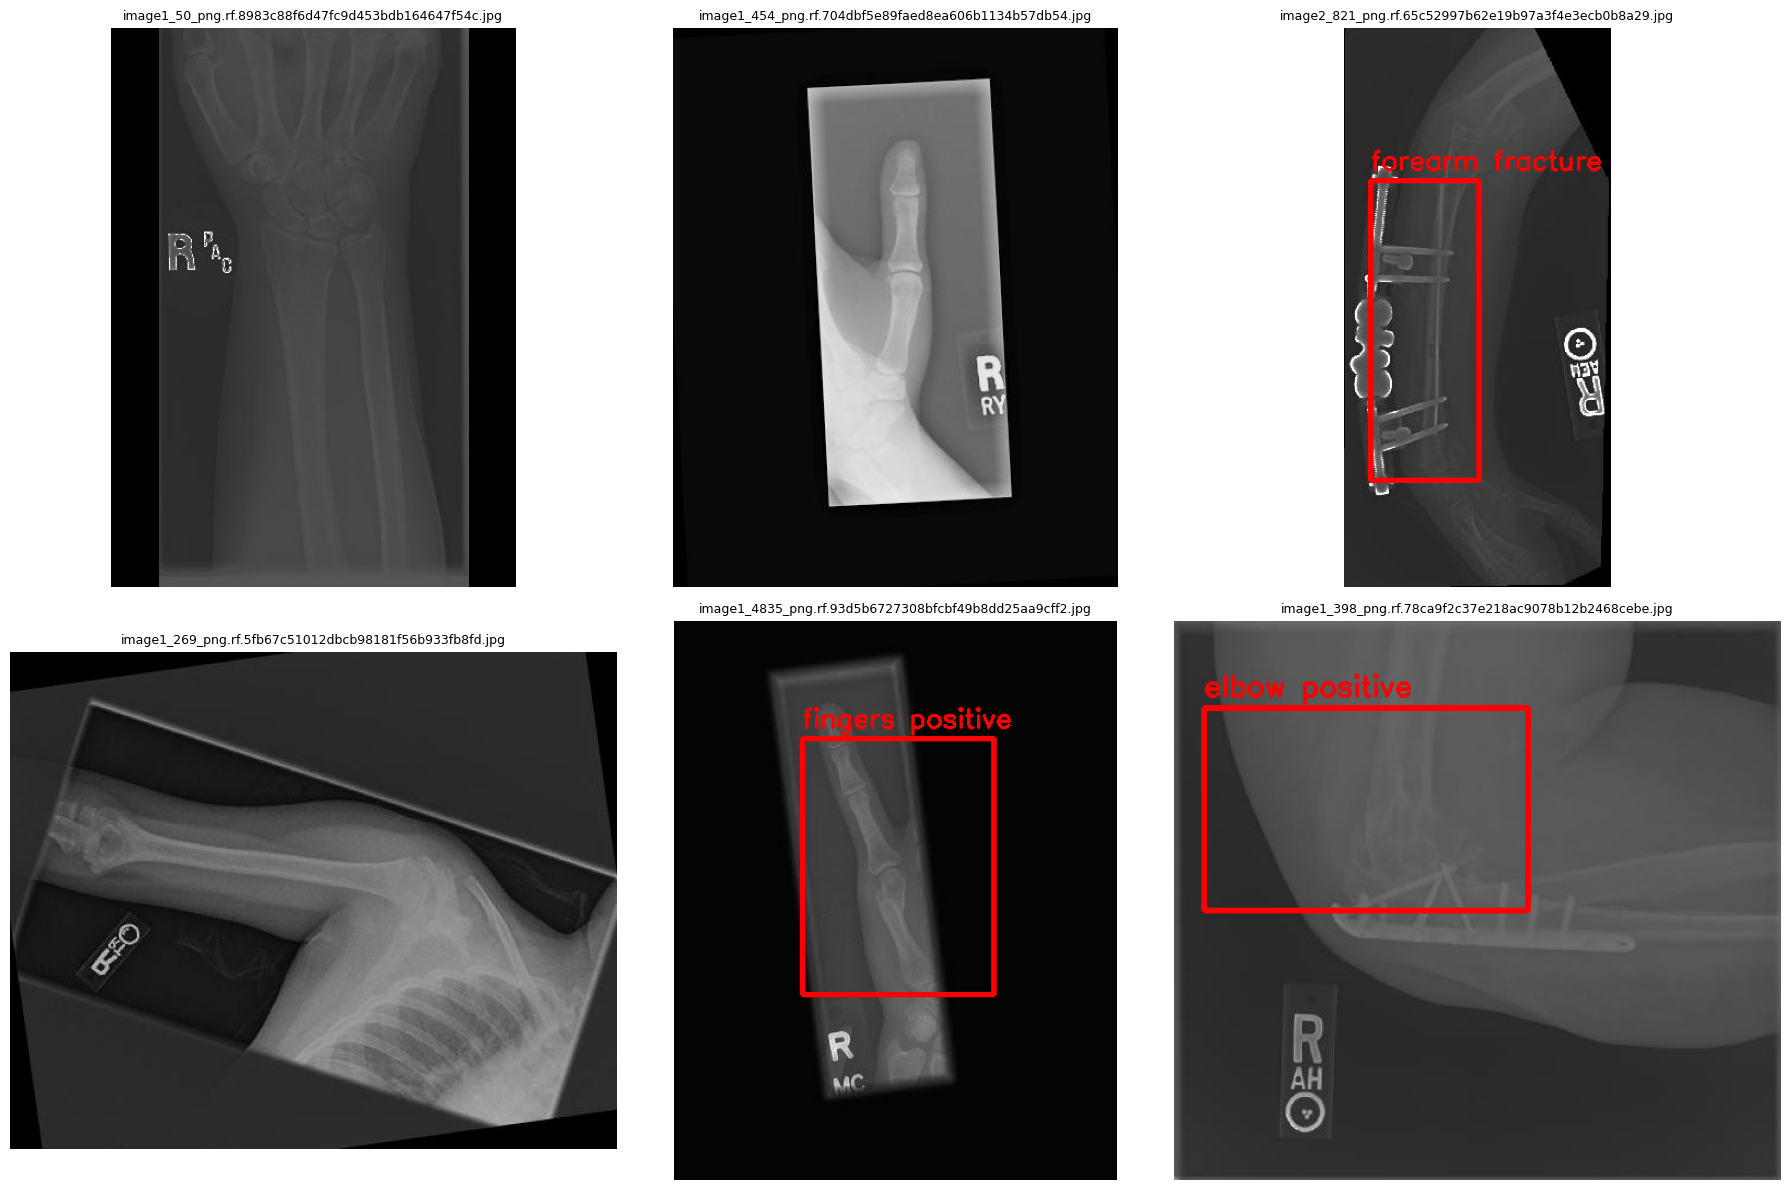

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

base = '/content/fracture_data/BoneFractureYolo8/train'
image_dir = os.path.join(base, 'images')
label_dir = os.path.join(base, 'labels')
names = ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus fracture', 'shoulder fracture', 'wrist positive']

image_files = os.listdir(image_dir)
sample = random.sample(image_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, fname in zip(axes.flatten(), sample):
    img_path = os.path.join(image_dir, fname)
    label_path = os.path.join(label_dir, os.path.splitext(fname)[0] + '.txt')

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:5])
                # YOLO format is normalized (0-1) center x/y, width/height
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                cv2.putText(img, names[cls], (x1, max(y1 - 10, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(fname, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os

image_dir = '/content/fracture_data/BoneFractureYolo8/train/images'
label_dir = '/content/fracture_data/BoneFractureYolo8/train/labels'

total = 0
truly_empty = 0

for fname in os.listdir(image_dir):
    total += 1
    label_path = os.path.join(label_dir, os.path.splitext(fname)[0] + '.txt')
    if not os.path.exists(label_path):
        truly_empty += 1
        continue
    with open(label_path) as f:
        content = f.read().strip()
    if content == '':
        truly_empty += 1

print(f"Total images: {total}")
print(f"Truly empty (no annotation): {truly_empty}")
print(f"Percentage: {100 * truly_empty / total:.1f}%")

Total images: 3631
Truly empty (no annotation): 1827
Percentage: 50.3%


Found 1827 empty-label images


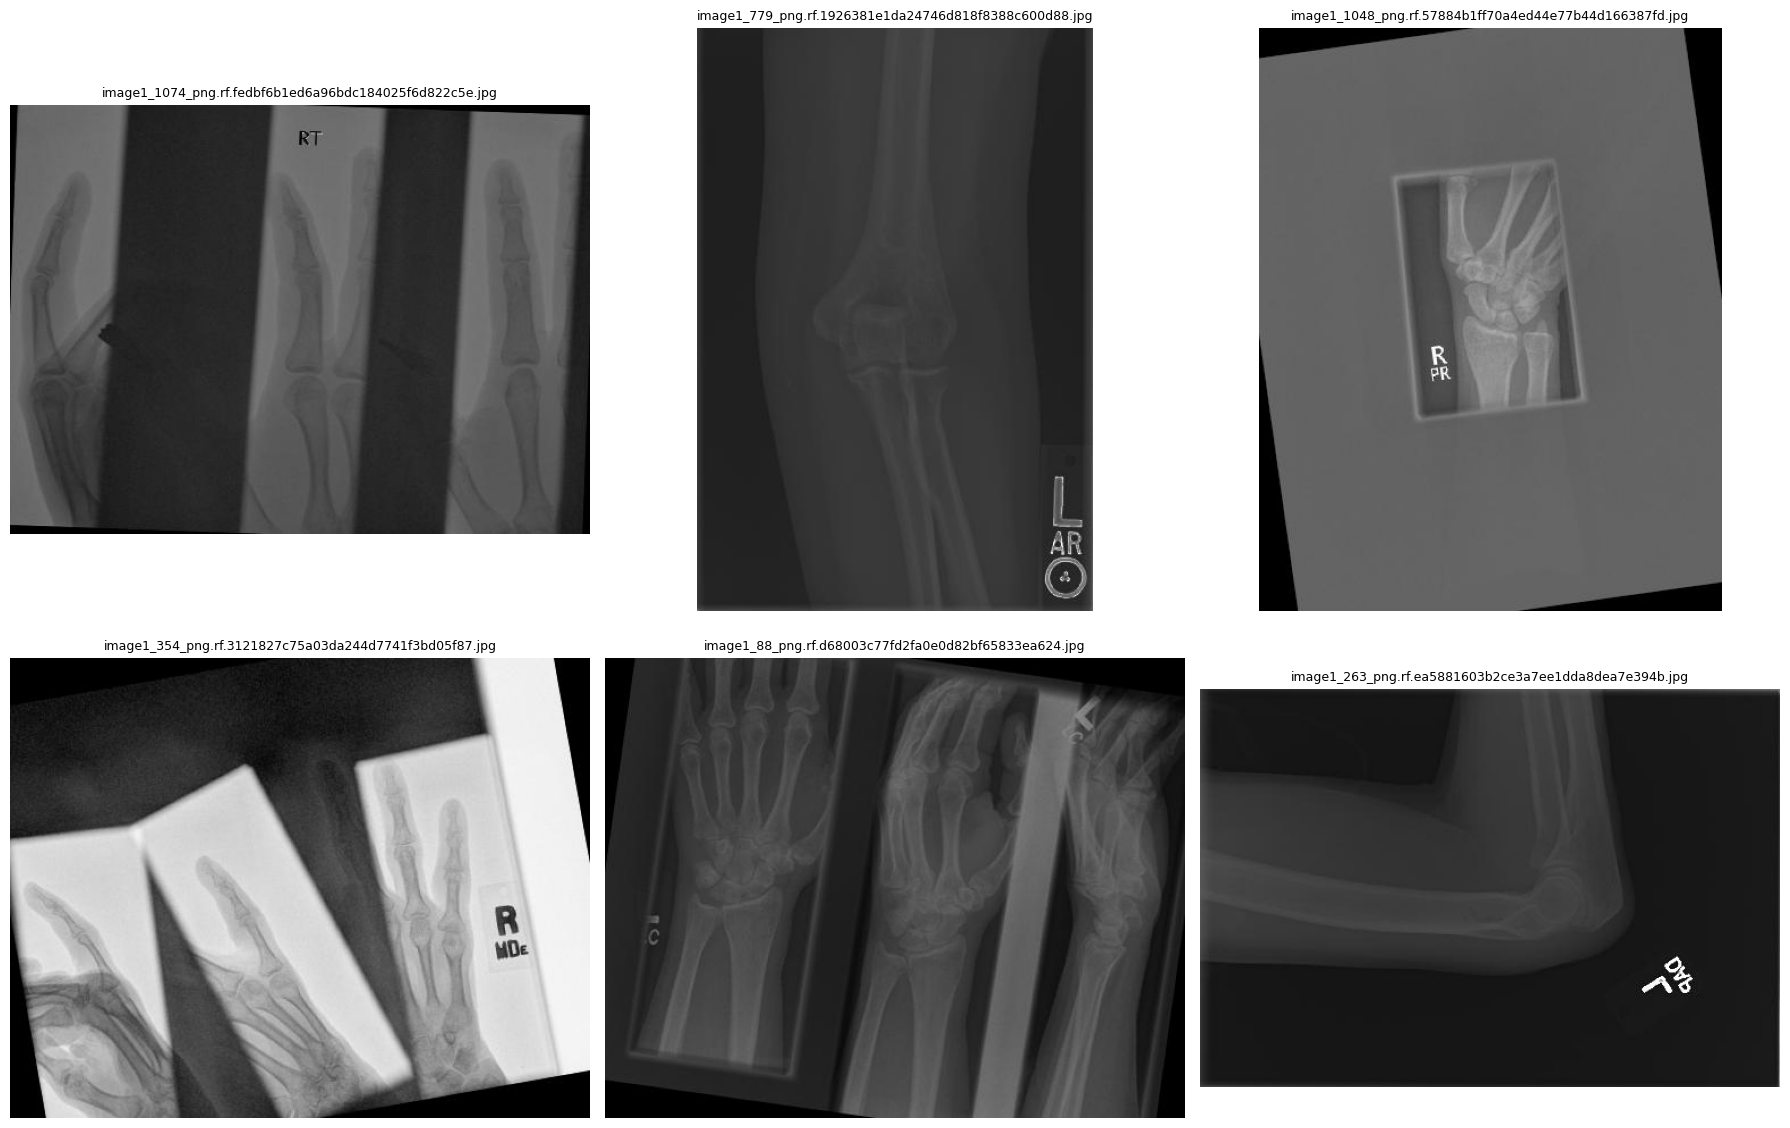

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

image_dir = '/content/fracture_data/BoneFractureYolo8/train/images'
label_dir = '/content/fracture_data/BoneFractureYolo8/train/labels'

empty_images = []
for fname in os.listdir(image_dir):
    label_path = os.path.join(label_dir, os.path.splitext(fname)[0] + '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            if f.read().strip() == '':
                empty_images.append(fname)

print(f"Found {len(empty_images)} empty-label images")
sample = random.sample(empty_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, fname in zip(axes.flatten(), sample):
    img = cv2.imread(os.path.join(image_dir, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(fname, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # small model — good balance of speed/accuracy for ~3.6k images on a T4

results = model.train(
    data='/content/fracture_data/BoneFractureYolo8/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,       # early stop if val mAP doesn't improve for 20 epochs
    project='fracture_detect',
    name='yolov8s_v1',
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fracture_data/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v1, nbs=64, nms=False, opset=None, optimize=False, opti

In [ ]:
from ultralytics import YOLO

best_model = YOLO('/content/runs/detect/fracture_detect/yolov8s_v1/weights/best.pt')
metrics = best_model.val(data='/content/fracture_data/BoneFractureYolo8/data.yaml')

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 441.0±197.6 MB/s, size: 13.9 KB)
val: Scanning /content/fracture_data/BoneFractureYolo8/valid/labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348 15.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 3.9it/s 5.7s
                   all        348        204      0.321      0.309      0.257     0.0925
        elbow positive         28         29      0.177      0.241       0.08     0.0189
      fingers positive         41         48      0.198      0.167       0.12     0.0428
      forearm fracture         37         43      0.488      0.488      0.449      0.181
      humerus fracture         31         36      0.685      0.483      0.564      0.189
     shoulder fracture

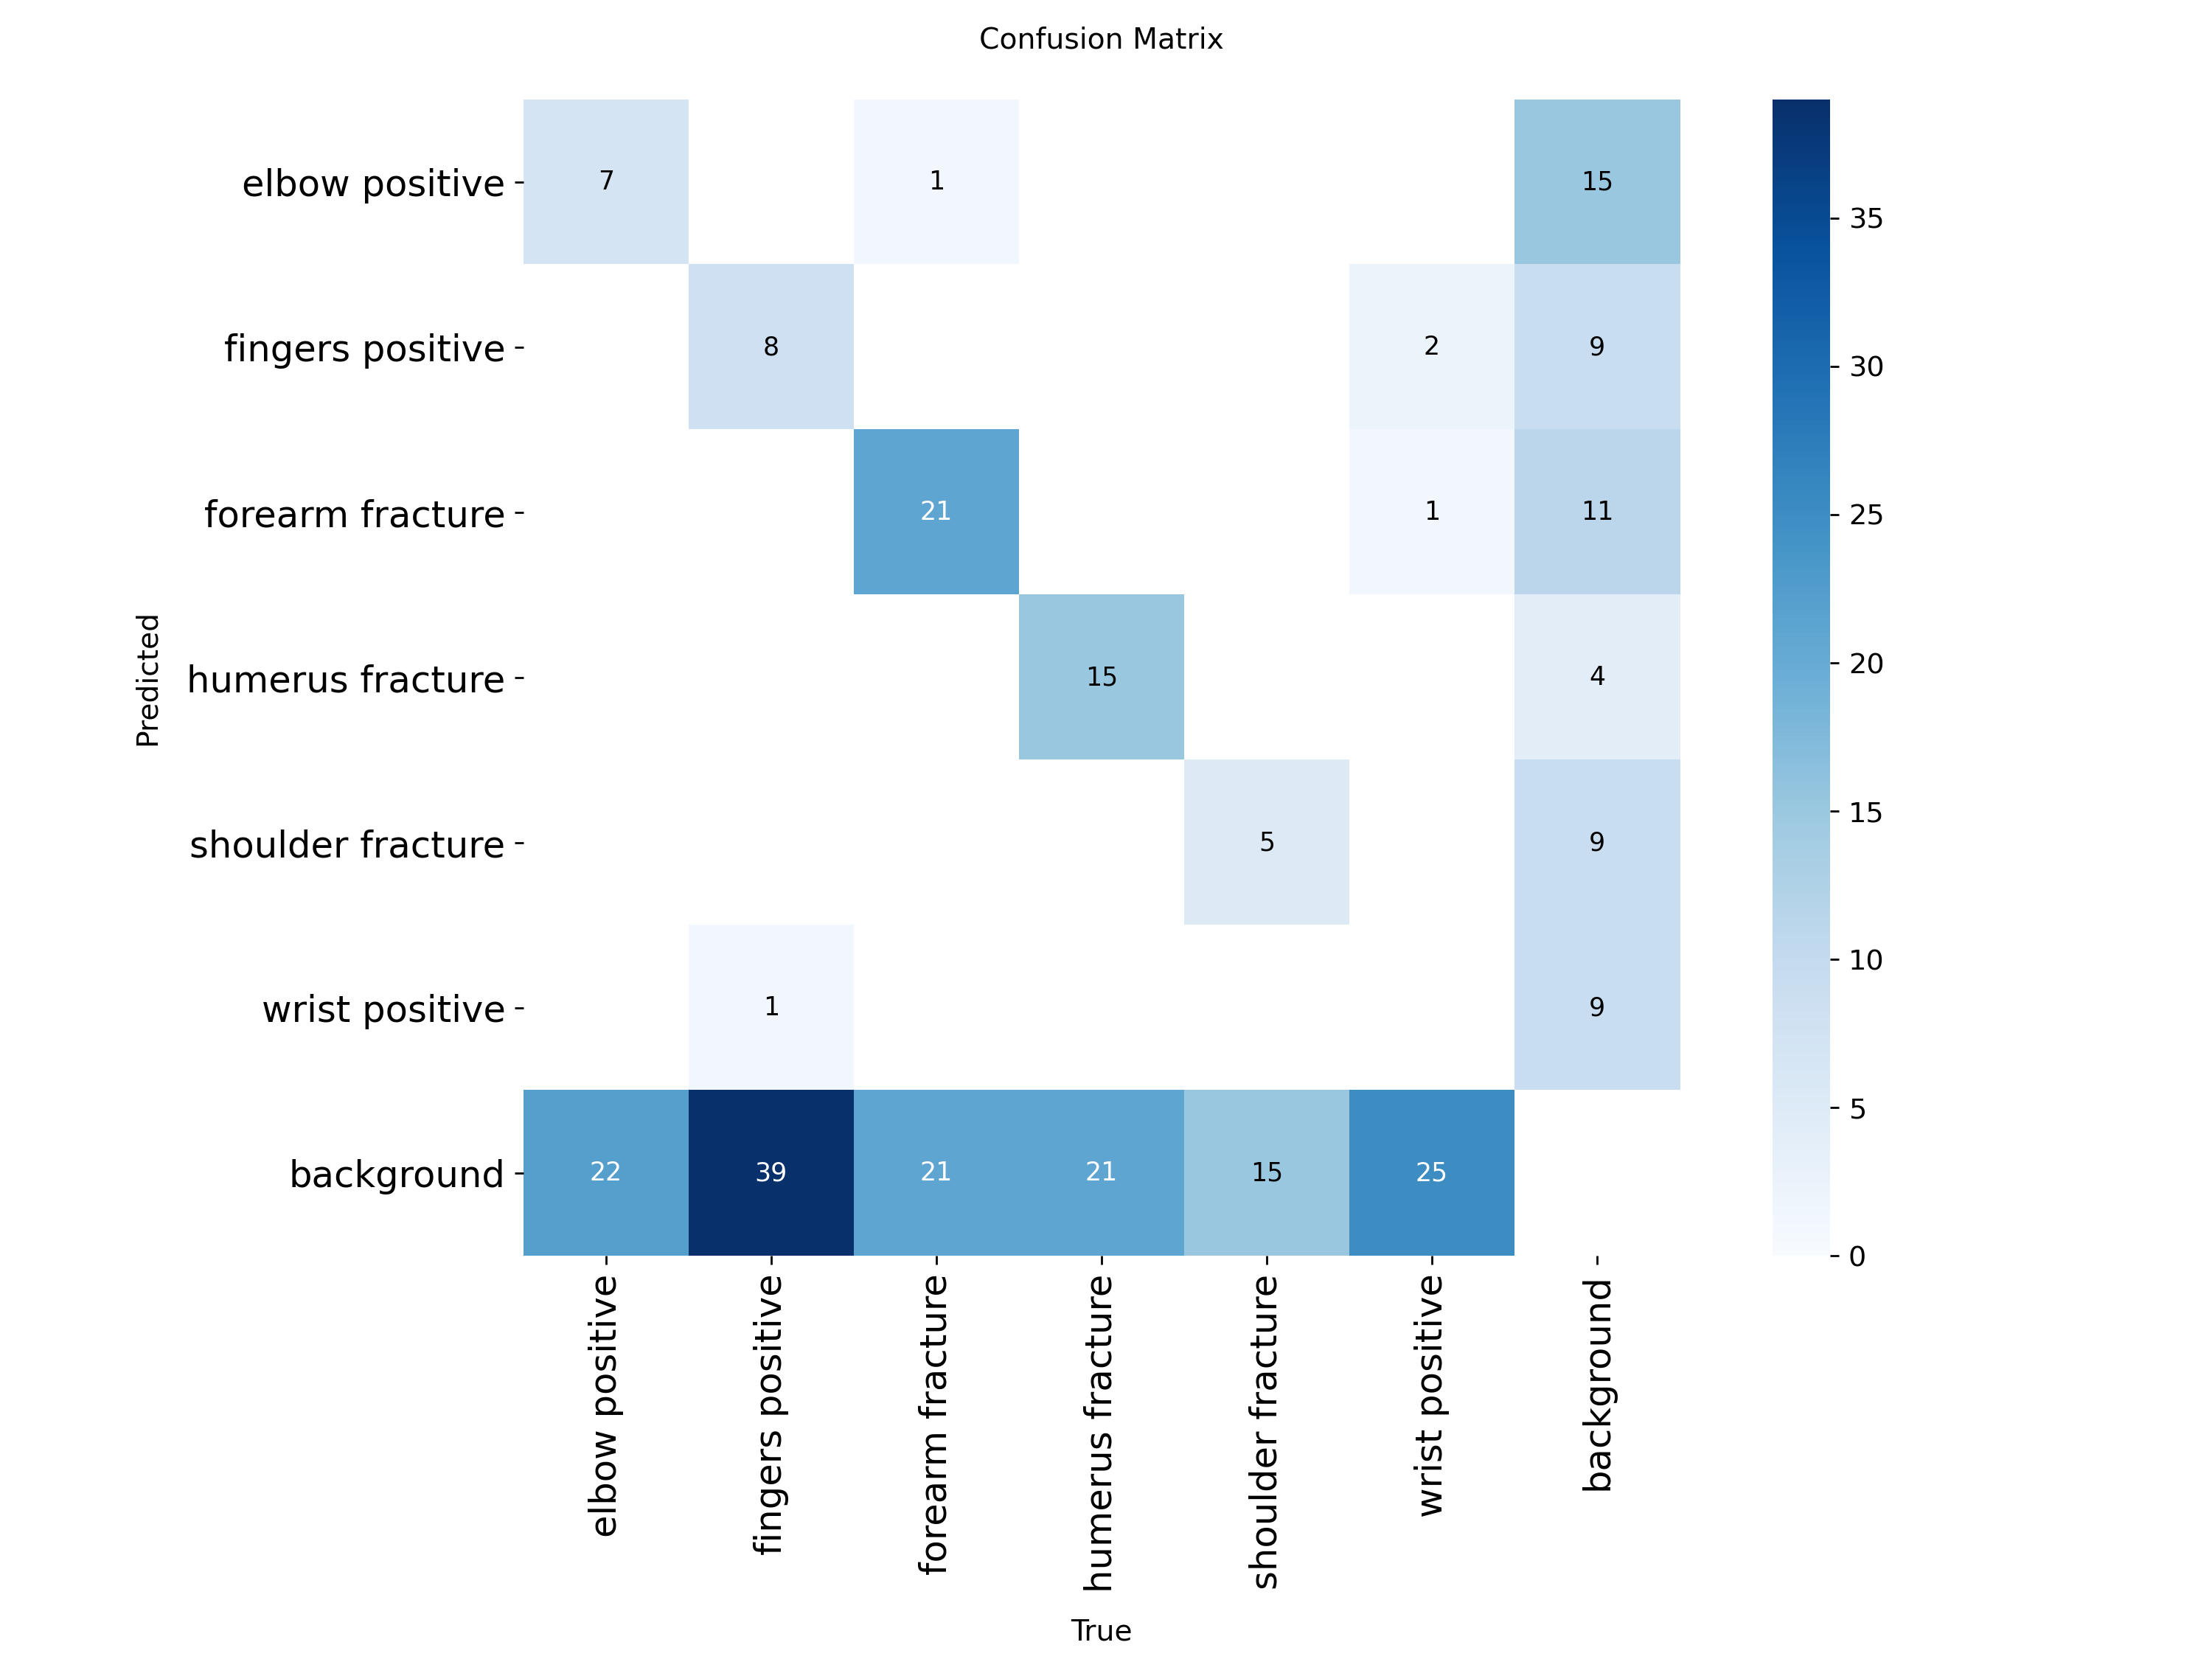

In [ ]:
from IPython.display import Image
Image('/content/runs/detect/val-2/confusion_matrix.png')  # path may have a different val number, check with !find

In [ ]:
import random

val_image_dir = '/content/fracture_data/BoneFractureYolo8/valid/images'
sample_files = random.sample(os.listdir(val_image_dir), 6)
sample_paths = [os.path.join(val_image_dir, f) for f in sample_files]

results = best_model.predict(sample_paths, conf=0.05, save=True, project='/content/runs', name='low_conf_check')


0: 640x640 1 fingers positive, 2 forearm fractures, 13.3ms
1: 640x640 (no detections), 13.3ms
2: 640x640 (no detections), 13.3ms
3: 640x640 (no detections), 13.3ms
4: 640x640 3 humerus fractures, 13.3ms
5: 640x640 (no detections), 13.3ms
Speed: 3.3ms preprocess, 13.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/low_conf_check


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='/content/fracture_data/BoneFractureYolo8/data.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    patience=0,          # don't stop early this time — let it use the full budget
    degrees=10,          # rotation augmentation — X-rays are taken at varying angles (we saw this in image 1)
    fliplr=0.5,          # left/right flip — anatomically valid for limb X-rays
    hsv_v=0.4,           # brightness variation — X-ray exposure varies a lot between machines
    translate=0.1,
    project='fracture_detect',
    name='yolov8s_v2',
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fracture_data/BoneFractureYolo8/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v2, nbs=64, nms=False, opset=None, optimize=False, optim

In [ ]:
# Save and download v2 weights immediately after training completes (Colab runtimes can disconnect)
!zip -r fracture_detect_v2.zip /content/runs/detect/fracture_detect/yolov8s_v2
from google.colab import files
files.download('fracture_detect_v2.zip')


  adding: content/runs/detect/fracture_detect/yolov8s_v2/ (stored 0%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/val_batch1_labels.jpg (deflated 15%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/weights/ (stored 0%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/weights/best.pt (deflated 8%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/weights/last.pt (deflated 8%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/confusion_matrix_normalized.png (deflated 19%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/val_batch2_pred.jpg (deflated 22%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/val_batch1_pred.jpg (deflated 15%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/train_batch0.jpg (deflated 16%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/val_batch0_pred.jpg (deflated 25%)
  adding: content/runs/detect/fracture_detect/yolov8s_v2/train_batch1.jpg (deflated 15%)
  adding: content/runs/det

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load v2 best checkpoint and validate
from ultralytics import YOLO
best_model_v2 = YOLO('/content/runs/detect/fracture_detect/yolov8s_v2/weights/best.pt')
metrics_v2 = best_model_v2.val(data='/content/fracture_data/BoneFractureYolo8/data.yaml')


Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 622.4±271.0 MB/s, size: 10.4 KB)
val: Scanning /content/fracture_data/BoneFractureYolo8/valid/labels.cache... 348 images, 175 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348 132.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.1it/s 5.4s
                   all        348        204      0.329      0.287       0.25     0.0931
        elbow positive         28         29      0.162      0.241     0.0878     0.0238
      fingers positive         41         48       0.28      0.208      0.173     0.0435
      forearm fracture         37         43      0.491      0.395      0.437      0.178
      humerus fracture         31         36      0.595      0.556       0.57      0.226
     shoulder fractur

In [ ]:
# Compare v1 (baseline) vs v2 (extended training + augmentation)
print("v1  mAP50:", 0.257, " mAP50-95:", 0.0925)
print("v2  mAP50:", metrics_v2.box.map50, " mAP50-95:", metrics_v2.box.map)


v1  mAP50: 0.257  mAP50-95: 0.0925
v2  mAP50: 0.2496629504277383  mAP50-95: 0.09306643634121634


In [ ]:
import numpy as np

def compute_alignment(p1, p2, p3, p4):
    """
    p1, p2, p3, p4: (x, y) tuples/arrays for the 4 keypoints, in pixel coordinates.
    p1-p2: proximal fragment axis (far -> near break)
    p3-p4: distal fragment axis (near break -> far)

    Returns:
        angle_deg: angulation between fragment axes, in degrees (0 = perfectly aligned)
        displacement_px: perpendicular offset between the two axes at the break point, in pixels
    """
    p1, p2, p3, p4 = map(np.array, (p1, p2, p3, p4))

    # Fragment direction vectors
    v_proximal = p2 - p1
    v_distal = p4 - p3

    # Angle between the two vectors (angulation)
    cos_angle = np.dot(v_proximal, v_distal) / (np.linalg.norm(v_proximal) * np.linalg.norm(v_distal))
    cos_angle = np.clip(cos_angle, -1.0, 1.0)  # guard against floating point drift outside [-1, 1]
    angle_rad = np.arccos(cos_angle)
    angle_deg = np.degrees(angle_rad)

    # A perfectly straight, aligned bone gives angle ~180° (vectors point opposite ways along one line)
    # so we report deviation from straight alignment, which is more clinically intuitive
    angulation_deg = 180 - angle_deg

    # Displacement: perpendicular distance from the break point (midpoint of P2, P3)
    # to the proximal fragment's axis line, extended
    break_point = (p2 + p3) / 2
    proximal_dir_unit = v_proximal / np.linalg.norm(v_proximal)

    # Vector from p1 to the break point, projected perpendicular to the proximal axis
    to_break = break_point - p1
    projection_length = np.dot(to_break, proximal_dir_unit)
    projected_point = p1 + projection_length * proximal_dir_unit
    displacement_px = np.linalg.norm(break_point - projected_point)

    return angulation_deg, displacement_px

In [ ]:
p1 = (100, 50)   # far point, proximal
p2 = (105, 150)  # near point, proximal (at break)

p3 = (115, 155)  # near point, distal (at break)
p4 = (130, 250)  # far point, distal

angulation, displacement = compute_alignment(p1, p2, p3, p4)
print(f"Angulation: {angulation:.2f} degrees")
print(f"Displacement: {displacement:.2f} pixels")

Angulation: 173.89 degrees
Displacement: 4.87 pixels


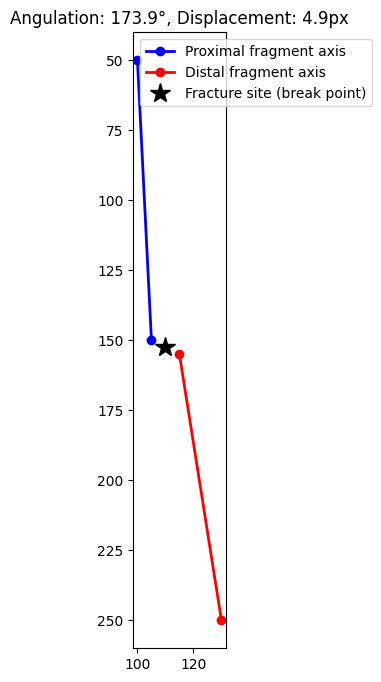

In [ ]:
import matplotlib.pyplot as plt

def plot_alignment(p1, p2, p3, p4, angulation, displacement):
    fig, ax = plt.subplots(figsize=(6, 8))
    p1, p2, p3, p4 = map(np.array, (p1, p2, p3, p4))

    ax.plot(*zip(p1, p2), 'b-o', label='Proximal fragment axis', linewidth=2)
    ax.plot(*zip(p3, p4), 'r-o', label='Distal fragment axis', linewidth=2)

    break_point = (p2 + p3) / 2
    ax.plot(*break_point, 'k*', markersize=15, label='Fracture site (break point)')

    ax.invert_yaxis()  # image coordinates: y increases downward
    ax.set_title(f'Angulation: {angulation:.1f}°, Displacement: {displacement:.1f}px')
    ax.legend()
    ax.set_aspect('equal')
    plt.show()

plot_alignment(p1, p2, p3, p4, angulation, displacement)

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_alignment_on_image(image_path, p1, p2, p3, p4, angulation, displacement):
    """
    Draws the 4 keypoints, fragment axis lines, a bounding rectangle around the
    fracture region, and the computed alignment metrics directly on the X-ray.
    """
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    p1, p2, p3, p4 = (tuple(map(int, p)) for p in (p1, p2, p3, p4))

    cv2.line(img, p1, p2, (0, 0, 255), 3)      # RGB blue: (R=0, G=0, B=255)
    cv2.line(img, p3, p4, (255, 140, 0), 3)    # RGB orange stays the same

    for pt in (p1, p2, p3, p4):
        cv2.circle(img, pt, 6, (0, 255, 0), -1)

    # Break point (midpoint of the two near-break keypoints)
    break_point = tuple(int(v) for v in ((np.array(p2) + np.array(p3)) / 2))
    cv2.drawMarker(img, break_point, (255, 0, 255), markerType=cv2.MARKER_STAR,
                    markerSize=20, thickness=2)

    all_x = [p1[0], p2[0], p3[0], p4[0]]
    all_y = [p1[1], p2[1], p3[1], p4[1]]
    margin = 20
    x_min, x_max = min(all_x) - margin, max(all_x) + margin
    y_min, y_max = min(all_y) - margin, max(all_y) + margin
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)

    fig, ax = plt.subplots(figsize=(8, 10))
    ax.imshow(img)
    ax.set_title(f'Predicted Fracture Region\nAngulation: {angulation:.1f}°   Displacement: {displacement:.1f}px',
                 fontsize=12)
    ax.axis('off')

    # Legend, drawn manually since these are raw cv2 shapes, not matplotlib artists
    legend_elements = [
        plt.Line2D([0], [0], color='blue', lw=3, label='Proximal fragment axis'),
        plt.Line2D([0], [0], color='orange', lw=3, label='Distal fragment axis'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='magenta',
                   markersize=15, label='Fracture site'),
        plt.Line2D([0], [0], color='yellow', lw=3, label='Fracture region (bounding box)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

    return break_point, (x_min, y_min, x_max, y_max)

In [ ]:
import os

# Pick a real forearm fracture image from validation set
image_dir = '/content/fracture_data/BoneFractureYolo8/valid/images'
label_dir = '/content/fracture_data/BoneFractureYolo8/valid/labels'

# find one labeled as forearm fracture (class index 2) to demo on
demo_image = None
for fname in os.listdir(label_dir):
    with open(os.path.join(label_dir, fname)) as f:
        content = f.read().strip()
        if content and content.split()[0] == '2':  # forearm fracture class
            demo_image = os.path.splitext(fname)[0] + '.jpg'
            break

print("Using:", demo_image)
img_path = os.path.join(image_dir, demo_image)

# check actual image dimensions first, so keypoints are placed sensibly
img_check = cv2.imread(img_path)
print("Image shape (h, w):", img_check.shape[:2])

Using: image2_604_png.rf.9087b8961228cd207e2d66f1dec266ef.jpg
Image shape (h, w): (512, 424)


Angulation: 177.80 degrees
Displacement: 8.61 pixels


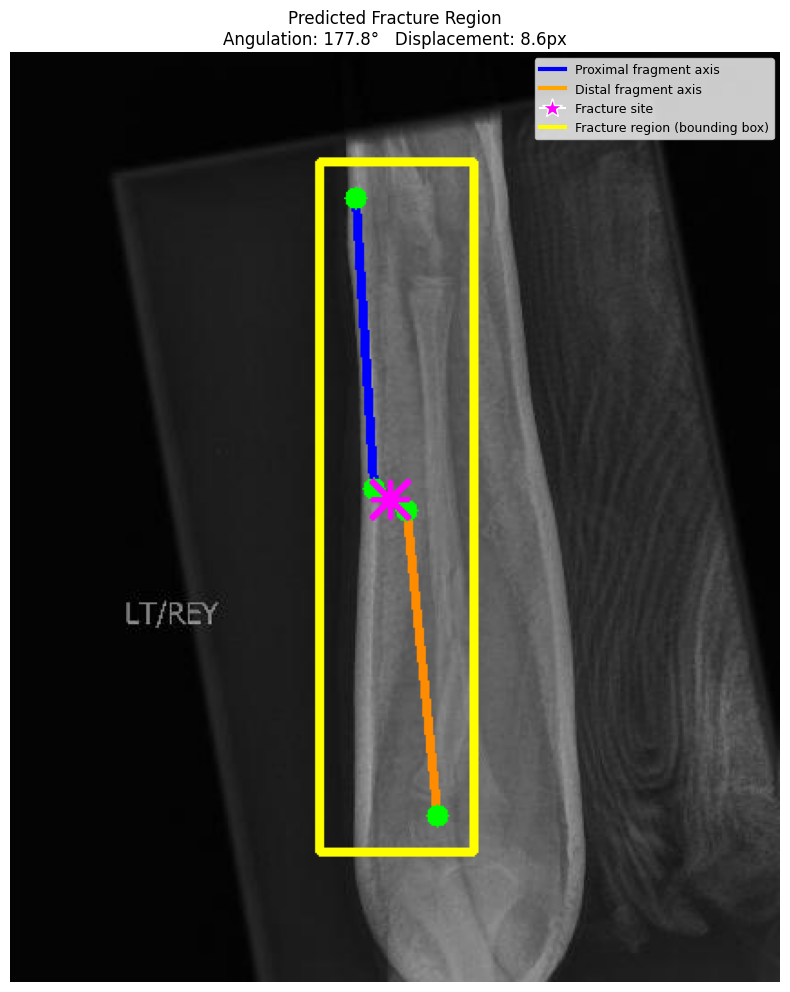

In [ ]:
p1 = (190, 80)    # proximal fragment, far point (upper forearm)
p2 = (200, 240)   # proximal fragment, near point (at break)
p3 = (218, 252)   # distal fragment, near point (at break) — slightly offset to show displacement
p4 = (235, 420)   # distal fragment, far point (lower forearm) — slightly angled to show angulation

angulation, displacement = compute_alignment(p1, p2, p3, p4)
print(f"Angulation: {angulation:.2f} degrees")
print(f"Displacement: {displacement:.2f} pixels")

break_point, bbox = visualize_alignment_on_image(img_path, p1, p2, p3, p4, angulation, displacement)